# Task 3: Text Classification with RNN/LSTM
Avishek kadel



In [3]:
# 4.5.1 - Imports and setup
import json
import random
import re
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from gensim import downloader as api
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import LSTM, SimpleRNN, Dense, Dropout, Embedding, SpatialDropout1D
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from wordcloud import WordCloud

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE = Path('/content/RNN')
BASE.mkdir(exist_ok=True)
OUT_DIR = BASE / 'task3_outputs'
OUT_DIR.mkdir(exist_ok=True)

ZIP_PATH = Path('/content/drive/MyDrive/AI-ML DATASET/4. Hate Speech Detection Dataset-20260506T102024Z-3-001.zip')

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(BASE)

# locate the CSV inside the extracted folder
csv_candidates = list(BASE.rglob('*.csv'))
print('Found CSVs:', csv_candidates)
DATA_PATH = csv_candidates[0]

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print('Dataset:', DATA_PATH)
print('Output dir:', OUT_DIR)

Mounted at /content/drive
Found CSVs: [PosixPath('/content/RNN/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv')]
Dataset: /content/RNN/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv
Output dir: /content/RNN/task3_outputs


In [2]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.5 MB/s eta 0:00:00


In [4]:
# 4.5.1 - Text cleaning helpers
CONTRACTIONS = {
    "don't": "do not", "can't": "can not", "won't": "will not", "i'm": "i am",
    "it's": "it is", "that's": "that is", "what's": "what is", "you're": "you are",
    "we're": "we are", "they're": "they are", "isn't": "is not", "aren't": "are not",
    "wasn't": "was not", "weren't": "were not", "didn't": "did not", "doesn't": "does not",
    "couldn't": "could not", "shouldn't": "should not", "wouldn't": "would not", "hasn't": "has not",
    "haven't": "have not", "hadn't": "had not", "n't": " not", "'re": " are", "'s": " is",
    "'d": " would", "'ll": " will", "'t": " not", "'ve": " have", "'m": " am",
}

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    # Lowercase
    text = str(text).lower()
    # Remove links, mentions, hashtags
    text = re.sub(r'https?://\\S+|www\\.\\S+', ' ', text)
    text = re.sub(r'@\\w+', ' ', text)
    text = re.sub(r'#\\w+', ' ', text)
    # Expand contractions
    for short, full in CONTRACTIONS.items():
        text = text.replace(short, full)
    # Keep alphabets only
    text = re.sub(r'[^a-z\\s]', ' ', text)
    text = re.sub(r'\\s+', ' ', text).strip()
    # Stopword removal + lemmatization
    tokens = [lemmatizer.lemmatize(tok) for tok in text.split() if tok not in stop_words and len(tok) > 1]
    return ' '.join(tokens)


In [5]:
# 4.5.1 - Load dataset, clean, label handling, tokenization, and padding
raw = pd.read_csv(DATA_PATH)

if 'class' in raw.columns:
    label_col = 'class'
elif 'label' in raw.columns:
    label_col = 'label'
else:
    raise ValueError(f'Could not find label column. Columns: {raw.columns.tolist()}')

if 'tweet' in raw.columns:
    text_col = 'tweet'
elif 'text' in raw.columns:
    text_col = 'text'
elif 'comment' in raw.columns:
    text_col = 'comment'
else:
    raise ValueError(f'Could not find text column. Columns: {raw.columns.tolist()}')

df = raw[[text_col, label_col]].dropna().copy()
df[text_col] = df[text_col].astype(str)
df['clean_text'] = df[text_col].apply(clean_text)
df = df[df['clean_text'].str.len() > 0].copy()

# Convert string labels if required
if pd.api.types.is_numeric_dtype(df[label_col]):
    df[label_col] = df[label_col].astype(int)
else:
    normalized = df[label_col].astype(str).str.strip().str.lower()
    label_map = {
        'hate speech': 0,
        'hate speec': 0,  # dataset typo retained as hate speech
        'hate': 0,
        'offensive language': 1,
        'offensive': 1,
        'neither': 2,
    }
    df[label_col] = normalized.map(label_map)
    df = df.dropna(subset=[label_col]).copy()
    df[label_col] = df[label_col].astype(int)

# Reindex labels to 0..N-1 for stable sparse categorical training
original_labels = sorted(df[label_col].unique().tolist())
label_to_idx = {lab: i for i, lab in enumerate(original_labels)}
idx_to_label = {i: lab for lab, i in label_to_idx.items()}
df['label_idx'] = df[label_col].map(label_to_idx).astype(int)

# 80/20 split
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'].values,
    df['label_idx'].values,
    test_size=0.2,
    random_state=SEED,
    stratify=df['label_idx'].values,
)

# Tokenization + percentile-based padding
tokenizer = Tokenizer(num_words=30000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_text)
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)
lengths = np.array([len(s) for s in X_train_seq])
max_len = max(int(np.percentile(lengths, 95)), 10)
X_train = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

num_classes = len(np.unique(y_train))
vocab_size = min(30000, len(tokenizer.word_index) + 1)
embedding_dim = 64

print('Rows:', len(df), 'Classes:', num_classes, 'Original labels:', original_labels)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape, 'Max len:', max_len)


Rows: 24783 Classes: 3 Original labels: [0, 1, 2]
Train shape: (19826, 16) Test shape: (4957, 16) Max len: 16


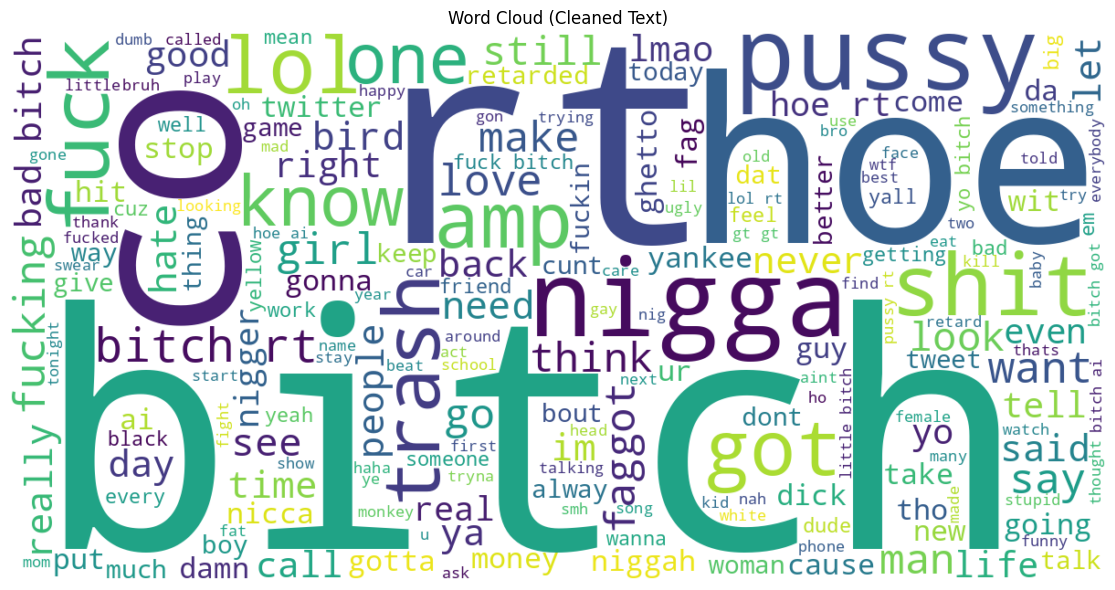

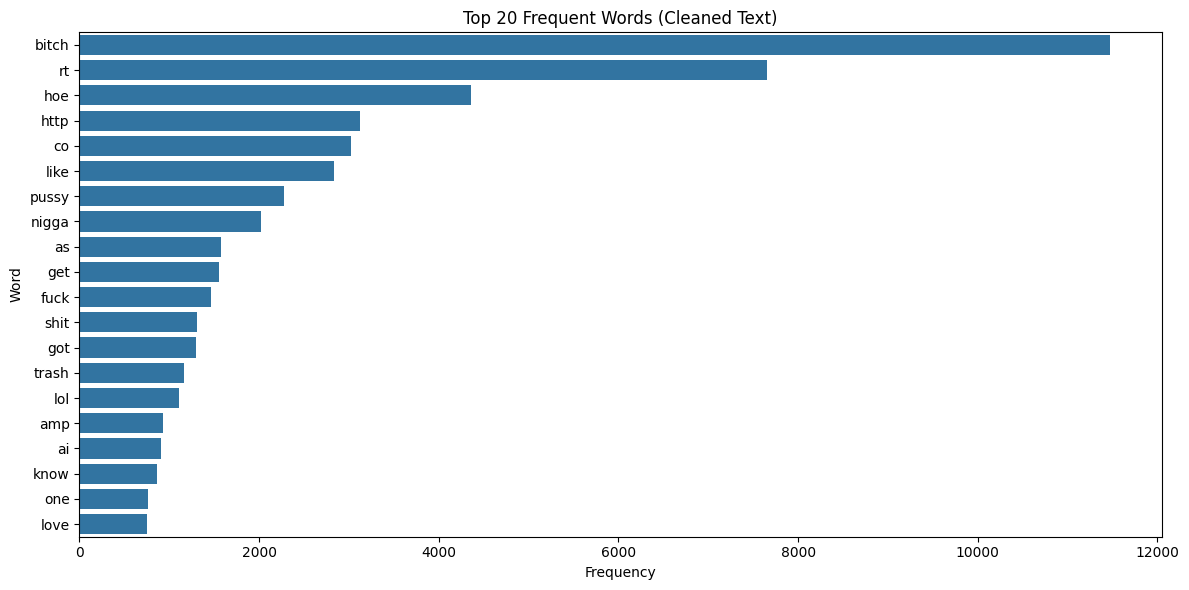

In [6]:
# 4.5.1 - Visualize cleaned text
all_words = ' '.join(df['clean_text'].tolist())

wordcloud = WordCloud(width=1200, height=600, background_color='white').generate(all_words)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud (Cleaned Text)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'wordcloud_cleaned.png', dpi=150)
plt.show()

word_freq = pd.Series(all_words.split()).value_counts().head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x=word_freq.values, y=word_freq.index)
plt.title('Top 20 Frequent Words (Cleaned Text)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.savefig(OUT_DIR / 'top20_words.png', dpi=150)
plt.show()


In [7]:


def build_rnn_model():

    return Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        SimpleRNN(32, dropout=0.2),
        Dense(16, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax'),
    ])


def build_lstm_model():

    return Sequential([
        Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_len),
        SpatialDropout1D(0.2),
        LSTM(32, dropout=0.2),
        Dense(16, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax'),
    ])


def build_lstm_w2v_model(embedding_matrix):

    return Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_matrix.shape[1],
            weights=[embedding_matrix],
            input_length=max_len,
            trainable=False,
        ),
        SpatialDropout1D(0.2),
        LSTM(32, dropout=0.2),
        Dense(16, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax'),
    ])


In [11]:
# 4.5.3 - Training and evaluation helpers

def plot_history(history, name):

    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    ax[0].plot(h['loss'], label='train')
    ax[0].plot(h['val_loss'], label='val')
    ax[0].set_title(f'{name} Loss')
    ax[0].legend()
    ax[1].plot(h['accuracy'], label='train')
    ax[1].plot(h['val_accuracy'], label='val')
    ax[1].set_title(f'{name} Accuracy')
    ax[1].legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'{name}_curves.png', dpi=150)
    plt.show()


def evaluate_model(model, X, y, name):

    probs = model.predict(X, verbose=0)
    pred = np.argmax(probs, axis=1)
    report = classification_report(y, pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y, pred)

    # Confusion matrix helps identify which classes are being confused with each other.
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'{name}_confusion.png', dpi=150)
    plt.show()
    return pred, report


def train_and_eval(model, name):

    model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

    # Early stopping is stricter now because validation loss increased quickly in the previous run.
    # min_delta avoids treating tiny validation-loss changes as meaningful improvement.
    early = EarlyStopping(monitor='val_loss', patience=1, min_delta=0.001, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=10,
        batch_size=128,
        callbacks=[early],
        verbose=1,
    )
    plot_history(history, name)
    pred, report = evaluate_model(model, X_test, y_test, name)
    return model, pred, report


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - accuracy: 0.7979 - loss: 0.5857 - val_accuracy: 0.8732 - val_loss: 0.3585
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8992 - loss: 0.3321 - val_accuracy: 0.8865 - val_loss: 0.3410
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9217 - loss: 0.2528 - val_accuracy: 0.8785 - val_loss: 0.3632


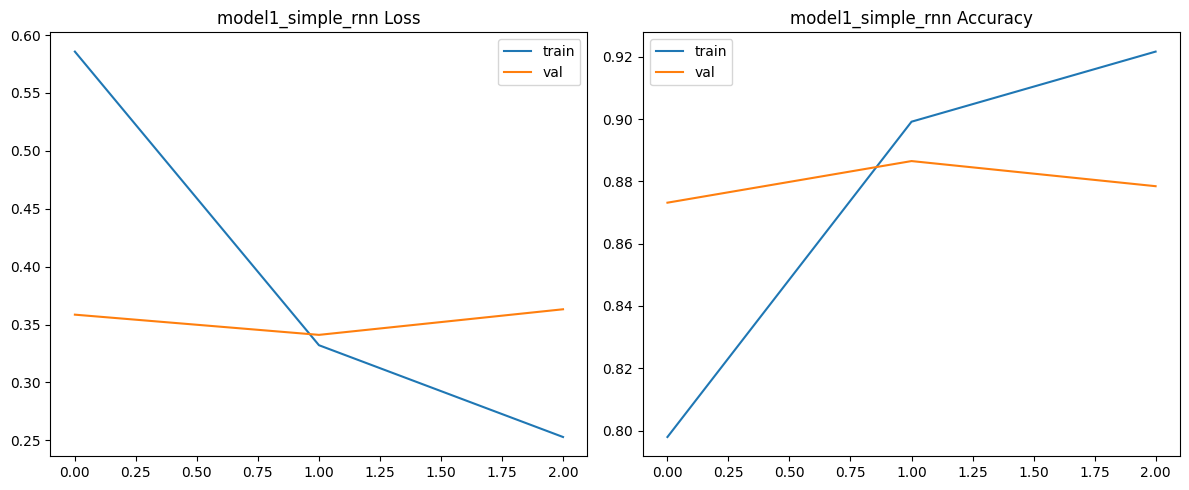

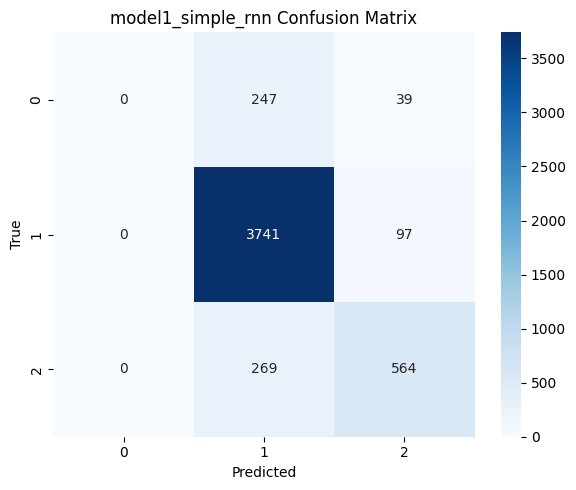

In [12]:
# 4.5.3 - Train Model 1: Regularized Simple RNN
# This is still the baseline model, but dropout and smaller hidden size reduce the overfitting seen earlier.
model1_ref, pred1, rep1 = train_and_eval(build_rnn_model(), 'model1_simple_rnn')


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7811 - loss: 0.6404 - val_accuracy: 0.8734 - val_loss: 0.3843
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8823 - loss: 0.3716 - val_accuracy: 0.8880 - val_loss: 0.3233
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9172 - loss: 0.2787 - val_accuracy: 0.8923 - val_loss: 0.3269


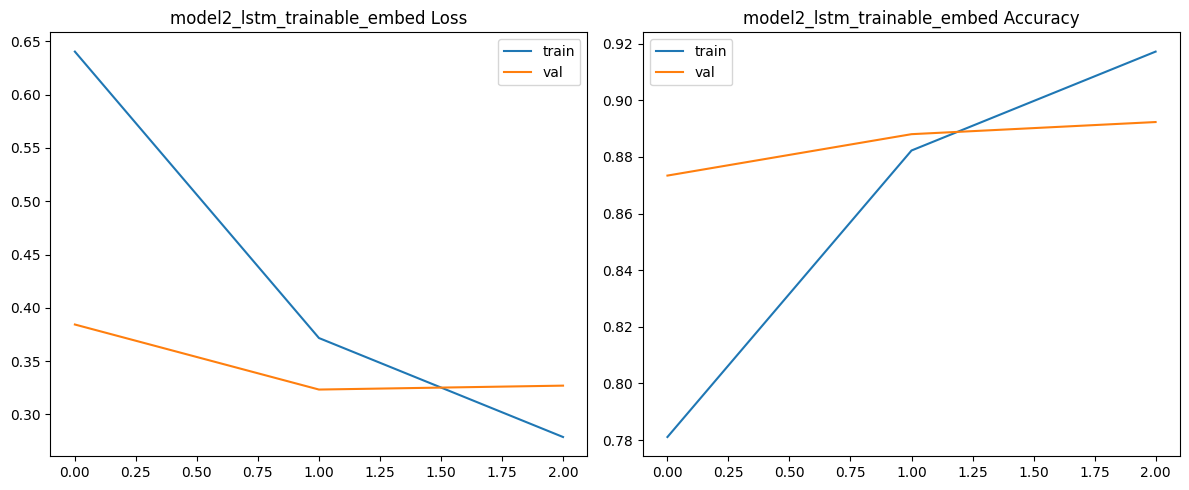

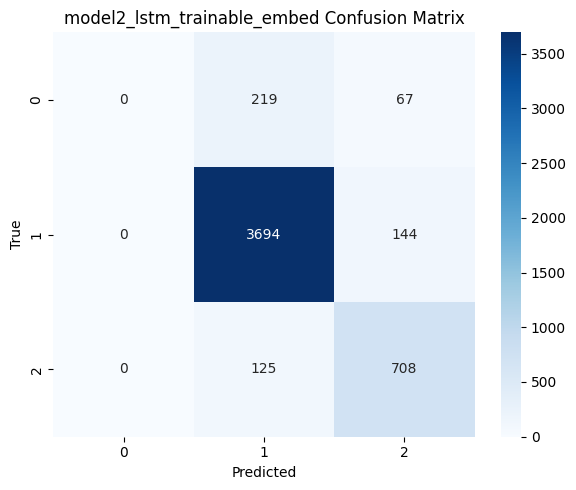

In [13]:
#
model2_ref, pred2, rep2 = train_and_eval(build_lstm_model(), 'model2_lstm_trainable_embed')


[==================================================] 100.0% 66.0/66.0MB downloaded
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7838 - loss: 0.6669 - val_accuracy: 0.8497 - val_loss: 0.4700
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8349 - loss: 0.5019 - val_accuracy: 0.8676 - val_loss: 0.4117
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8484 - loss: 0.4526 - val_accuracy: 0.8717 - val_loss: 0.3773
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8553 - loss: 0.4207 - val_accuracy: 0.8727 - val_loss: 0.3514
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8594 - loss: 0.4103 - val_accuracy: 0.8797 - val_loss: 0.3371
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8641 - loss: 0.3959 - val_accuracy: 0.8790 - val_loss: 0.3368


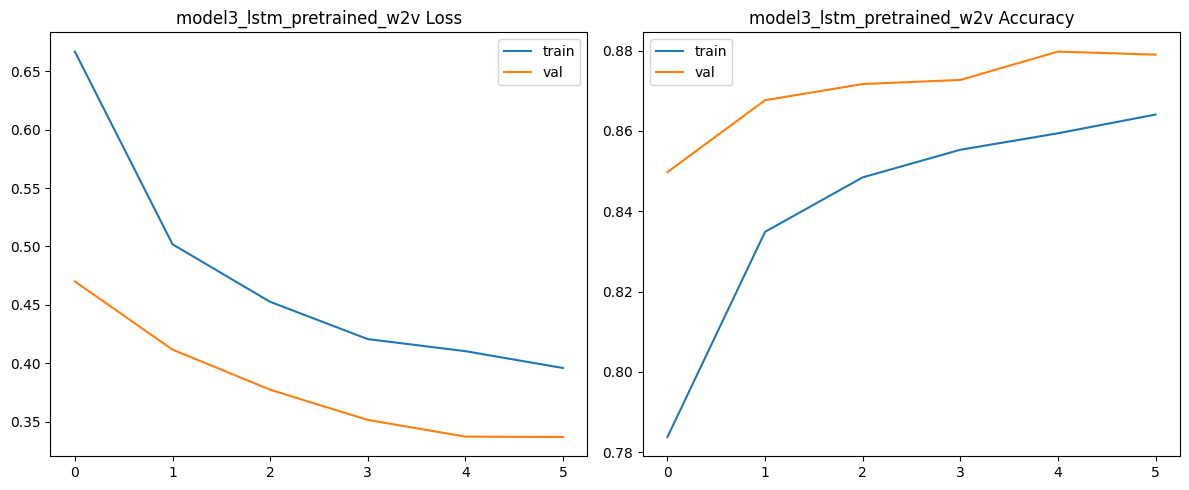

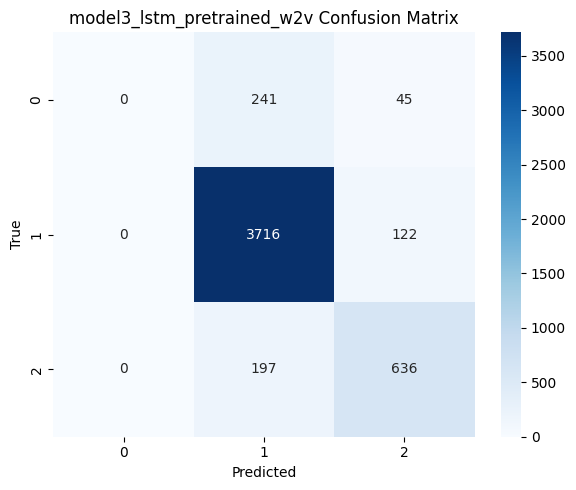

In [14]:

embedding_model = api.load('glove-wiki-gigaword-50')
emb_dim = embedding_model.vector_size
embedding_matrix = np.zeros((vocab_size, emb_dim))

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]

model3_ref, pred3, rep3 = train_and_eval(
    build_lstm_w2v_model(embedding_matrix),
    'model3_lstm_pretrained_w2v'
)


In [15]:
# 4.5.3 + 4.5.4 - Compare models, save reports, and show sample errors
reports = {
    'model1_simple_rnn': rep1,
    'model2_lstm_trainable_embed': rep2,
    'model3_lstm_pretrained_w2v': rep3,
}
preds = {
    'model1_simple_rnn': pred1,
    'model2_lstm_trainable_embed': pred2,
    'model3_lstm_pretrained_w2v': pred3,
}

best_name = max(reports.keys(), key=lambda k: reports[k]['accuracy'])
best_pred = preds[best_name]

errors = []
for text, true_idx, pred_idx in zip(X_test_text, y_test, best_pred):
    if int(true_idx) != int(pred_idx):
        errors.append({
            'text': text,
            'true_reindexed': int(true_idx),
            'pred_reindexed': int(pred_idx),
            'true_original_label': int(idx_to_label[int(true_idx)]),
            'pred_original_label': int(idx_to_label[int(pred_idx)]),
        })
    if len(errors) >= 3:
        break

summary = {
    'dataset_rows': int(len(df)),
    'train_size': int(len(X_train)),
    'test_size': int(len(X_test)),
    'vocab_size': int(vocab_size),
    'max_len_95_percentile': int(max_len),
    'label_distribution_original': pd.Series(df[label_col]).value_counts().sort_index().to_dict(),
    'original_label_values': original_labels,
    'best_model': best_name,
    'sample_misclassifications': errors,
    'model_metrics': {
        name: {
            'accuracy': rep['accuracy'],
            'macro_f1': rep['macro avg']['f1-score'],
        }
        for name, rep in reports.items()
    },
}

with open(OUT_DIR / 'metrics_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

for name, report in reports.items():
    pd.DataFrame(report).transpose().to_csv(OUT_DIR / f'{name}_classification_report.csv')

print('Best model:', best_name)
summary


Best model: model2_lstm_trainable_embed


{'dataset_rows': 24783,
 'train_size': 19826,
 'test_size': 4957,
 'vocab_size': 28762,
 'max_len_95_percentile': 16,
 'label_distribution_original': {0: 1430, 1: 19190, 2: 4163},
 'original_label_values': [0, 1, 2],
 'best_model': 'model2_lstm_trainable_embed',
 'sample_misclassifications': [{'text': 'rt obeyyreggie stfu hoe rt tedddydgaf proud african american proud african american proud white racist',
   'true_reindexed': 0,
   'pred_reindexed': 1,
   'true_original_label': 0,
   'pred_original_label': 1},
  {'text': 'makeitsndgood fewjr block u see happens think ya high yellow as watch',
   'true_reindexed': 1,
   'pred_reindexed': 2,
   'true_original_label': 1,
   'pred_original_label': 2},
  {'text': 'glenladen got life flight osu saving mess bird respect',
   'true_reindexed': 2,
   'pred_reindexed': 1,
   'true_original_label': 2,
   'pred_original_label': 1}],
 'model_metrics': {'model1_simple_rnn': {'accuracy': 0.8684688319548114,
   'macro_f1': 0.553362125477502},
  'model

## 4.5.5 Optional GUI for Real-Time Prediction
This section creates a small Gradio interface where a user can enter a tweet/comment and receive the predicted class from the best trained model.


In [17]:
# 4.5.4b - Save artifacts for standalone deployment
import pickle
import json

final_model.save(OUT_DIR / 'best_model.keras')

with open(OUT_DIR / 'tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

deploy_config = {
    'max_len': max_len,
    'idx_to_label': idx_to_label,
    'label_names': {0: 'hate speech', 1: 'offensive language', 2: 'neither'},
}
with open(OUT_DIR / 'deploy_config.json', 'w') as f:
    json.dump(deploy_config, f)

print('Saved to', OUT_DIR)

Saved to /content/RNN/task3_outputs


In [ ]:
# 4.5.5 - Standalone real-time prediction GUI with Gradio
import json
import pickle
import re

import gradio as gr
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

ARTIFACT_DIR = OUT_DIR  # change to wherever you place the 3 saved files

final_model = load_model(ARTIFACT_DIR / 'best_model.keras')

with open(ARTIFACT_DIR / 'tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

with open(ARTIFACT_DIR / 'deploy_config.json') as f:
    deploy_config = json.load(f)

max_len = deploy_config['max_len']
idx_to_label = {int(k): v for k, v in deploy_config['idx_to_label'].items()}
label_names = {int(k): v for k, v in deploy_config['label_names'].items()}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return text.strip()

def predict_text(user_text):
    cleaned = clean_text(user_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=max_len, padding='post', truncating='post')
    probabilities = final_model.predict(padded, verbose=0)[0]
    predicted_idx = int(np.argmax(probabilities))
    original_label = int(idx_to_label[predicted_idx])
    predicted_name = label_names.get(original_label, str(original_label))
    confidence = float(probabilities[predicted_idx])
    return {
        'prediction': predicted_name,
        'original_label': original_label,
        'confidence': round(confidence, 4),
        'cleaned_text': cleaned,
    }

interface = gr.Interface(
    fn=predict_text,
    inputs=gr.Textbox(lines=4, label='Enter tweet/comment'),
    outputs=gr.JSON(label='Prediction'),
    title='Hate vs Offensive Language Classifier',
    description='Real-time prediction using the trained model.'
)

gr.close_all()
interface.launch(share=True, debug=True)

Closing server running on port: 7860
Closing server running on port: 7861
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3aa5f542975823ae30.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


/usr/local/lib/python3.12/dist-packages/gradio/routes.py:1379: StarletteDeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
